# DATA SELECTION AND CLEANING

The purpose of this notebook is to:
- Select data from the given data set that is required to answer our business quetions.
- Join them if need be.
- Clean the data.
- Finally save that data as a file that we will use on another notebook to answer our project objectives.

## DATA SELECTION 

We decided to use the **im.db** file to extract data from 3 tables namely **movie_basics**, **movie_akas** and **movie_ratings**

Using SQL we managed to queery the database im to extract the data we needed through the following process:

In [36]:
#Import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
#Connect to im db
conn = sqlite3.connect('DATA/im.db')
pd.read_sql("""
SELECT * FROM sqlite_master
WHERE TYPE = 'table';
""", conn)

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


In [38]:
#Looking at the ratings table
ratings = pd.read_sql("""
SELECT * FROM movie_ratings;
""", conn)
ratings.head(10)

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21
5,tt1069246,6.2,326
6,tt1094666,7.0,1613
7,tt1130982,6.4,571
8,tt1156528,7.2,265
9,tt1161457,4.2,148


In [39]:
#Look at the movie basics info
basics = pd.read_sql("""
SELECT * FROM movie_basics;
""", conn)
basics.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [40]:
#Looking at the movies akas info
akas = pd.read_sql("""
SELECT * FROM movie_akas;
""", conn)
akas

,movie_id,ordering,title,region,language,types,attributes,is_original_title
0,tt0369610,10,Джурасик свят,BG,bg,None,None,0.0
1,tt0369610,11,Jurashikku warudo,JP,None,imdbDisplay,None,0.0
2,tt0369610,12,Jurassic World: O Mundo dos Dinossauros,BR,None,imdbDisplay,None,0.0
3,tt0369610,13,O Mundo dos Dinossauros,BR,None,None,short title,0.0
4,tt0369610,14,Jurassic World,FR,None,imdbDisplay,None,0.0
...,...,...,...,...,...,...,...,...
331698,tt9827784,2,Sayonara kuchibiru,None,None,original,None,1.0
331699,tt9827784,3,Farewell Song,XWW,en,imdbDisplay,None,0.0
331700,tt9880178,1,La atención,None,None,original,None,1.0
331701,tt9880178,2,La atención,ES,None,None,None,0.0


In [41]:
null_regions = akas[akas['region'].isnull()]
null_regions

,movie_id,ordering,title,region,language,types,attributes,is_original_title
38,tt0369610,45,Jurassic World,None,None,original,None,1.0
80,tt0401729,7,John Carter,None,None,original,None,1.0
83,tt10010134,1,Versailles Rediscovered - The Sun King's Vanis...,None,None,original,None,1.0
86,tt10027708,1,Miguelito - Canto a Borinquen,None,None,original,None,1.0
90,tt10050722,1,Thing I Don't Get,None,None,original,None,1.0
...,...,...,...,...,...,...,...,...
331690,tt9723084,2,Anderswo. Allein in Afrika,None,None,original,None,1.0
331692,tt9726638,2,Monkey King: The Volcano,None,None,original,None,1.0
331696,tt9755806,3,Big Shark,None,None,original,None,1.0
331698,tt9827784,2,Sayonara kuchibiru,None,None,original,None,1.0


In [42]:
#Joining all the data in movie_basics and movie_ratings table

df = pd.read_sql("""
SELECT
    movie_basics.movie_id,
    movie_basics.primary_title,
    movie_basics.start_year,
    movie_basics.genres,
    movie_basics.runtime_minutes,
    movie_ratings.averagerating,
    movie_ratings.numvotes
FROM movie_basics
JOIN movie_ratings USING(movie_id);
""", conn)
df

,movie_id,primary_title,start_year,genres,runtime_minutes,averagerating,numvotes
0,tt0063540,Sunghursh,2013,"Action,Crime,Drama",175.0,7.0,77
1,tt0066787,One Day Before the Rainy Season,2019,"Biography,Drama",114.0,7.2,43
2,tt0069049,The Other Side of the Wind,2018,Drama,122.0,6.9,4517
3,tt0069204,Sabse Bada Sukh,2018,"Comedy,Drama",NaN,6.1,13
4,tt0100275,The Wandering Soap Opera,2017,"Comedy,Drama,Fantasy",80.0,6.5,119
...,...,...,...,...,...,...,...
73851,tt9913084,Diabolik sono io,2019,Documentary,75.0,6.2,6
73852,tt9914286,Sokagin Çocuklari,2019,"Drama,Family",98.0,8.7,136
73853,tt9914642,Albatross,2017,Documentary,NaN,8.5,8
73854,tt9914942,La vida sense la Sara Amat,2019,None,NaN,6.6,5


In [43]:
# After storin the data in our df we can now cleen it and check for missing and null null values
df.isna().sum()

movie_id              0
primary_title         0
start_year            0
genres              804
runtime_minutes    7620
averagerating         0
numvotes              0
dtype: int64

In [44]:
#Scince the only null values are in genres and they are less than 1 percent we can drop all the columns with genres missing
df = df.dropna()
df.isna().sum()

movie_id           0
primary_title      0
start_year         0
genres             0
runtime_minutes    0
averagerating      0
numvotes           0
dtype: int64

In [45]:
#Now we can post the dtat to a csv file so that we can merge with the 'bom.movie_gross csv file'.
df.to_csv('DATA/im.csv', index=False)

In [46]:
#Loadig the newly im.csv file so we cn merge with the bom.movie_gross.csv file
df_info = pd.read_csv('DATA/im.csv')
df_info.head()

,movie_id,primary_title,start_year,genres,runtime_minutes,averagerating,numvotes
0,tt0063540,Sunghursh,2013,"Action,Crime,Drama",175.0,7.0,77
1,tt0066787,One Day Before the Rainy Season,2019,"Biography,Drama",114.0,7.2,43
2,tt0069049,The Other Side of the Wind,2018,Drama,122.0,6.9,4517
3,tt0100275,The Wandering Soap Opera,2017,"Comedy,Drama,Fantasy",80.0,6.5,119
4,tt0137204,Joe Finds Grace,2017,"Adventure,Animation,Comedy",83.0,8.1,263


In [47]:
#load the data in bom.movie_gross to inspect it 1st
df_gross = pd.read_csv('DATA/bom.movie_gross.csv')
df_gross

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


In [48]:
#Look at all the missing data if any on this file
df_gross.isna().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [49]:
#Ensure the title names for both files are consistent to one another
df_info['title_clean'] = df_info['primary_title'].str.strip().str.lower()

df_gross['title_clean'] = df_gross['title'].str.strip().str.lower()


In [50]:
#Now we can merge the 2 files using the title clean column
df_merged = df_info.merge(df_gross, on='title_clean', how='left')
df_merged

,movie_id,primary_title,start_year,genres,runtime_minutes,averagerating,numvotes,title_clean,title,studio,domestic_gross,foreign_gross,year
0,tt0063540,Sunghursh,2013,"Action,Crime,Drama",175.0,7.0,77,sunghursh,NaN,NaN,NaN,NaN,NaN
1,tt0066787,One Day Before the Rainy Season,2019,"Biography,Drama",114.0,7.2,43,one day before the rainy season,NaN,NaN,NaN,NaN,NaN
2,tt0069049,The Other Side of the Wind,2018,Drama,122.0,6.9,4517,the other side of the wind,NaN,NaN,NaN,NaN,NaN
3,tt0100275,The Wandering Soap Opera,2017,"Comedy,Drama,Fantasy",80.0,6.5,119,the wandering soap opera,NaN,NaN,NaN,NaN,NaN
4,tt0137204,Joe Finds Grace,2017,"Adventure,Animation,Comedy",83.0,8.1,263,joe finds grace,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65717,tt9911774,Padmavyuhathile Abhimanyu,2019,Drama,130.0,8.4,365,padmavyuhathile abhimanyu,NaN,NaN,NaN,NaN,NaN
65718,tt9913056,Swarm Season,2019,Documentary,86.0,6.2,5,swarm season,NaN,NaN,NaN,NaN,NaN
65719,tt9913084,Diabolik sono io,2019,Documentary,75.0,6.2,6,diabolik sono io,NaN,NaN,NaN,NaN,NaN
65720,tt9914286,Sokagin Çocuklari,2019,"Drama,Family",98.0,8.7,136,sokagin çocuklari,NaN,NaN,NaN,NaN,NaN


In [51]:
# We can now check for matched rows so as to keep them
matched = df_merged['domestic_gross'].notna().sum()
matched

3056

In [52]:
#save the matched data to a new df
movies_df = df_merged[df_merged['domestic_gross'].notna()]
movies_df.head()

,movie_id,primary_title,start_year,genres,runtime_minutes,averagerating,numvotes,title_clean,title,studio,domestic_gross,foreign_gross,year
23,tt0315642,Wazir,2016,"Action,Crime,Drama",103.0,7.1,15378,wazir,Wazir,Relbig.,1100000.0,NaN,2016.0
30,tt0337692,On the Road,2012,"Adventure,Drama,Romance",124.0,6.1,37886,on the road,On the Road,IFC,744000.0,8000000,2012.0
34,tt0359950,The Secret Life of Walter Mitty,2013,"Adventure,Comedy,Drama",114.0,7.3,275300,the secret life of walter mitty,The Secret Life of Walter Mitty,Fox,58200000.0,129900000,2013.0
38,tt0365907,A Walk Among the Tombstones,2014,"Action,Crime,Drama",114.0,6.5,105116,a walk among the tombstones,A Walk Among the Tombstones,Uni.,26300000.0,26900000,2014.0
39,tt0369610,Jurassic World,2015,"Action,Adventure,Sci-Fi",124.0,7.0,539338,jurassic world,Jurassic World,Uni.,652300000.0,"1,019.4",2015.0


In [53]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3056 entries, 23 to 65713
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         3056 non-null   object 
 1   primary_title    3056 non-null   object 
 2   start_year       3056 non-null   int64  
 3   genres           3056 non-null   object 
 4   runtime_minutes  3056 non-null   float64
 5   averagerating    3056 non-null   float64
 6   numvotes         3056 non-null   int64  
 7   title_clean      3056 non-null   object 
 8   title            3056 non-null   object 
 9   studio           3055 non-null   object 
 10  domestic_gross   3056 non-null   float64
 11  foreign_gross    1819 non-null   object 
 12  year             3056 non-null   float64
dtypes: float64(4), int64(2), object(7)
memory usage: 334.2+ KB


In [54]:
#Droping repeated columns and movie_id column
movies_df = movies_df.drop(columns = ['movie_id', 'title_clean', 'title', 'year'])
movies_df.head()

,primary_title,start_year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
23,Wazir,2016,"Action,Crime,Drama",103.0,7.1,15378,Relbig.,1100000.0,NaN
30,On the Road,2012,"Adventure,Drama,Romance",124.0,6.1,37886,IFC,744000.0,8000000
34,The Secret Life of Walter Mitty,2013,"Adventure,Comedy,Drama",114.0,7.3,275300,Fox,58200000.0,129900000
38,A Walk Among the Tombstones,2014,"Action,Crime,Drama",114.0,6.5,105116,Uni.,26300000.0,26900000
39,Jurassic World,2015,"Action,Adventure,Sci-Fi",124.0,7.0,539338,Uni.,652300000.0,"1,019.4"


In [55]:
#Renaming columns
movies_df = movies_df.rename(columns = {'primary_title': 'title'})
movies_df = movies_df.rename(columns = {'start_year': 'year'})
movies_df

,title,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
23,Wazir,2016,"Action,Crime,Drama",103.0,7.1,15378,Relbig.,1100000.0,NaN
30,On the Road,2012,"Adventure,Drama,Romance",124.0,6.1,37886,IFC,744000.0,8000000
34,The Secret Life of Walter Mitty,2013,"Adventure,Comedy,Drama",114.0,7.3,275300,Fox,58200000.0,129900000
38,A Walk Among the Tombstones,2014,"Action,Crime,Drama",114.0,6.5,105116,Uni.,26300000.0,26900000
39,Jurassic World,2015,"Action,Adventure,Sci-Fi",124.0,7.0,539338,Uni.,652300000.0,"1,019.4"
...,...,...,...,...,...,...,...,...,...
64842,Eden,2018,Drama,97.0,6.7,20,BG,65500.0,NaN
64924,Unstoppable,2018,"Action,Crime",116.0,6.5,576,Fox,81600000.0,86200000
65185,Neighbors,2018,"Comedy,Drama",90.0,7.6,18,Uni.,150200000.0,120500000
65239,The Gambler,2019,"Action,Sci-Fi,Thriller",121.0,6.1,10,Par.,33700000.0,5600000


In [56]:
#Save this dataframe to the final csv file called movies.csv
movies_df.to_csv('DATA/movies.csv', index = False)

In [57]:
df = pd.read_csv('DATA/movies.csv')
df

,title,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
0,Wazir,2016,"Action,Crime,Drama",103.0,7.1,15378,Relbig.,1100000.0,NaN
1,On the Road,2012,"Adventure,Drama,Romance",124.0,6.1,37886,IFC,744000.0,8000000
2,The Secret Life of Walter Mitty,2013,"Adventure,Comedy,Drama",114.0,7.3,275300,Fox,58200000.0,129900000
3,A Walk Among the Tombstones,2014,"Action,Crime,Drama",114.0,6.5,105116,Uni.,26300000.0,26900000
4,Jurassic World,2015,"Action,Adventure,Sci-Fi",124.0,7.0,539338,Uni.,652300000.0,"1,019.4"
...,...,...,...,...,...,...,...,...,...
3051,Eden,2018,Drama,97.0,6.7,20,BG,65500.0,NaN
3052,Unstoppable,2018,"Action,Crime",116.0,6.5,576,Fox,81600000.0,86200000
3053,Neighbors,2018,"Comedy,Drama",90.0,7.6,18,Uni.,150200000.0,120500000
3054,The Gambler,2019,"Action,Sci-Fi,Thriller",121.0,6.1,10,Par.,33700000.0,5600000


In [58]:
df.duplicated().sum()

0

In [59]:
df.isna().sum()

title                 0
year                  0
genres                0
runtime_minutes       0
averagerating         0
numvotes              0
studio                1
domestic_gross        0
foreign_gross      1237
dtype: int64

In [60]:
df[df['studio'].isna()]

,title,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
1814,Plot for Peace,2013,"Documentary,History,Thriller",84.0,6.7,128,NaN,7100.0,NaN


In [61]:
df['foreign_gross'] = df['foreign_gross'].fillna(0)
df.isna().sum()

title              0
year               0
genres             0
runtime_minutes    0
averagerating      0
numvotes           0
studio             1
domestic_gross     0
foreign_gross      0
dtype: int64

In [62]:
df = df.dropna(subset=['studio'])
df.isna().sum()

title              0
year               0
genres             0
runtime_minutes    0
averagerating      0
numvotes           0
studio             0
domestic_gross     0
foreign_gross      0
dtype: int64

In [63]:
df.head()

,title,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
0,Wazir,2016,"Action,Crime,Drama",103.0,7.1,15378,Relbig.,1100000.0,0
1,On the Road,2012,"Adventure,Drama,Romance",124.0,6.1,37886,IFC,744000.0,8000000
2,The Secret Life of Walter Mitty,2013,"Adventure,Comedy,Drama",114.0,7.3,275300,Fox,58200000.0,129900000
3,A Walk Among the Tombstones,2014,"Action,Crime,Drama",114.0,6.5,105116,Uni.,26300000.0,26900000
4,Jurassic World,2015,"Action,Adventure,Sci-Fi",124.0,7.0,539338,Uni.,652300000.0,"1,019.4"


In [64]:
df['foreign_gross'].dtype

dtype('O')

In [65]:
df['foreign_gross'] = df['foreign_gross'].replace('[\$,]', '', regex=True)
df['foreign_gross'] = pd.to_numeric(df['foreign_gross'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3055 entries, 0 to 3055
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            3055 non-null   object 
 1   year             3055 non-null   int64  
 2   genres           3055 non-null   object 
 3   runtime_minutes  3055 non-null   float64
 4   averagerating    3055 non-null   float64
 5   numvotes         3055 non-null   int64  
 6   studio           3055 non-null   object 
 7   domestic_gross   3055 non-null   float64
 8   foreign_gross    3055 non-null   float64
dtypes: float64(4), int64(2), object(3)
memory usage: 238.7+ KB


<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Lewis\AppData\Local\Temp\ipykernel_6260\2724456578.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['foreign_gross'] = df['foreign_gross'].replace('[\$,]', '', regex=True)
C:\Users\Lewis\AppData\Local\Temp\ipykernel_6260\2724456578.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['foreign_gross'] = df['foreign_gross'].replace('[\$,]', '', regex=True)
C:\Users\Lewis\AppData\Local\Temp\ipykernel_6260\2724456578.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

In [66]:
df.head()

,title,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
0,Wazir,2016,"Action,Crime,Drama",103.0,7.1,15378,Relbig.,1100000.0,0.0
1,On the Road,2012,"Adventure,Drama,Romance",124.0,6.1,37886,IFC,744000.0,8000000.0
2,The Secret Life of Walter Mitty,2013,"Adventure,Comedy,Drama",114.0,7.3,275300,Fox,58200000.0,129900000.0
3,A Walk Among the Tombstones,2014,"Action,Crime,Drama",114.0,6.5,105116,Uni.,26300000.0,26900000.0
4,Jurassic World,2015,"Action,Adventure,Sci-Fi",124.0,7.0,539338,Uni.,652300000.0,1019.4


In [67]:
df = df.rename(columns = {'title' : 'movie'})
df.head()

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
0,Wazir,2016,"Action,Crime,Drama",103.0,7.1,15378,Relbig.,1100000.0,0.0
1,On the Road,2012,"Adventure,Drama,Romance",124.0,6.1,37886,IFC,744000.0,8000000.0
2,The Secret Life of Walter Mitty,2013,"Adventure,Comedy,Drama",114.0,7.3,275300,Fox,58200000.0,129900000.0
3,A Walk Among the Tombstones,2014,"Action,Crime,Drama",114.0,6.5,105116,Uni.,26300000.0,26900000.0
4,Jurassic World,2015,"Action,Adventure,Sci-Fi",124.0,7.0,539338,Uni.,652300000.0,1019.4


In [68]:
df = df[df['year'] != 2019].copy()
df['total_gross'] = df['domestic_gross'] + df['foreign_gross']

In [69]:
df.to_csv('DATA/movies.csv', index = False)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3045 entries, 0 to 3053
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie            3045 non-null   object 
 1   year             3045 non-null   int64  
 2   genres           3045 non-null   object 
 3   runtime_minutes  3045 non-null   float64
 4   averagerating    3045 non-null   float64
 5   numvotes         3045 non-null   int64  
 6   studio           3045 non-null   object 
 7   domestic_gross   3045 non-null   float64
 8   foreign_gross    3045 non-null   float64
 9   total_gross      3045 non-null   float64
dtypes: float64(5), int64(2), object(3)
memory usage: 261.7+ KB


In [70]:
df = pd.read_csv('DATA/movies.csv')
df.head()

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross,total_gross
0,Wazir,2016,"Action,Crime,Drama",103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0
1,On the Road,2012,"Adventure,Drama,Romance",124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0
2,The Secret Life of Walter Mitty,2013,"Adventure,Comedy,Drama",114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0
3,A Walk Among the Tombstones,2014,"Action,Crime,Drama",114.0,6.5,105116,Uni.,26300000.0,26900000.0,53200000.0
4,Jurassic World,2015,"Action,Adventure,Sci-Fi",124.0,7.0,539338,Uni.,652300000.0,1019.4,652301019.4


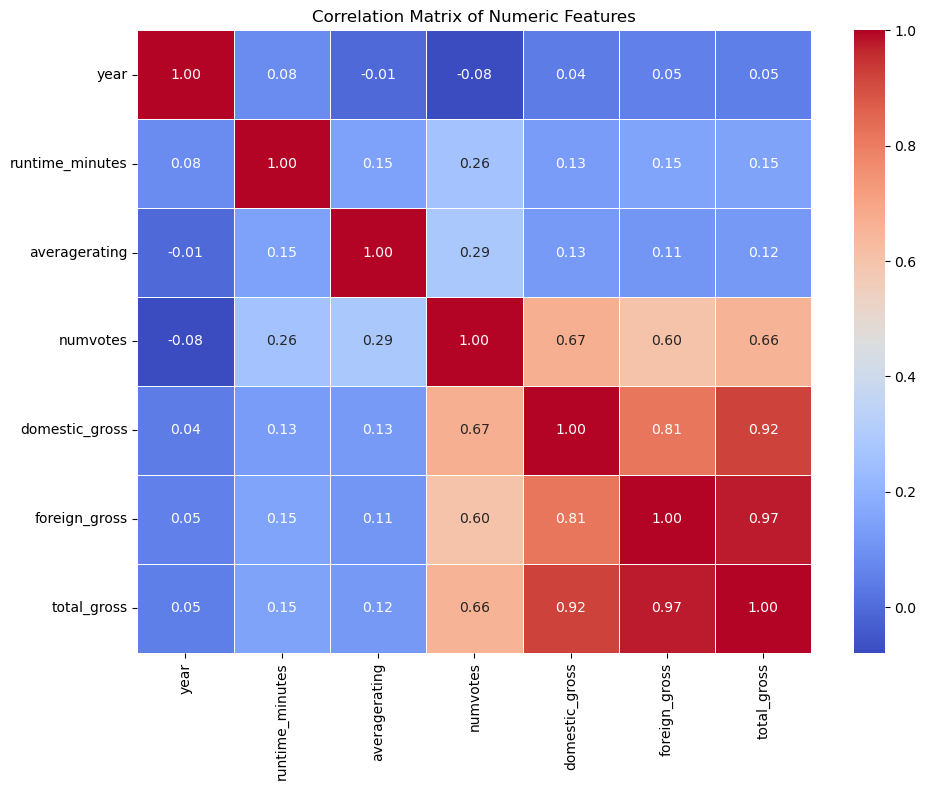

In [ ]:
numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()